# RPD02 - Data Collection with Cameras  (SO-101 - LeRobot - ROCm)

### Lab Description

With teleoperation working (RPD01), this lab records the **demonstration dataset** that every policy in this series learns from. You detect and preview your two USB cameras, run teleoperation with both camera feeds, then use `lerobot-record` to capture episodes -- motor states plus synchronized camera images -- as a `LeRobotDataset` saved locally on the host so it survives the container. The consistency and quality of *your own* recording is the single biggest factor in how well the trained policies (RPD03, RPD04) perform.

## Lab Overview

| Step | Topic | Key Concepts |
|------|-------|-------------|
| 1 | Verify the Environment | PyTorch, ROCm, GPU availability |
| 2 | Detect Cameras | `lerobot-find-cameras`, OpenCV camera index |
| 3 | Test Teleoperation with Camera | `lerobot-teleoperate` with `--robot.cameras`, `--display_data` |
| 4 | Record a Dataset | `lerobot-record`, episodes, local storage |
| 5 | Inspect the Dataset | Verify recorded data on disk |

#### Recommended Hardware

- Two SO-101 arms (one leader, one follower) with Feetech STS3215 servos
- USB hub connecting both arms to the host machine
- Two USB cameras (e.g. front and side views)

#### Software Environment

Docker container built from `Dockerfile` with [LeRobot](https://github.com/huggingface/lerobot) v0.5.0+ and ROCm PyTorch.\
Launch with `run.sh` (GPU + USB devices mounted).

#### Prerequisites

- Completed **RPD01** (teleoperation working, calibration verified)
- Two USB cameras connected to the host machine **before** starting the container

## Goals

1. **Detect Cameras**: Find available camera devices and their indices.
2. **Preview Camera Feed**: Run teleoperation with live camera display.
3. **Record Demonstration Data**: Capture episodes of teleoperated demonstrations with camera observations.
4. **Store Data Locally**: Save the dataset to a local directory for offline training.
5. **Inspect the Dataset**: Verify the recorded files on disk.


## 1. Verify the Environment

In [3]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.9.1+rocm7.11.0
CUDA available: True


## 2. Detect Cameras

Before recording, we need to find the camera device path (e.g. `/dev/video1`).

### Option A: `lerobot-find-cameras` (may time out)

Run in a **JupyterLab Terminal** (File → New → Terminal):

```bash
lerobot-find-cameras opencv
```

> **Known issue:** `lerobot-find-cameras` uses a 1000ms timeout with the default YUYV codec, which is often too short for USB cameras to deliver the first frame. It may report errors even for working cameras. If it fails, use Option B below instead.

### Option B: Python test (recommended)

The following cell probes each `/dev/video*` device using MJPG codec, which is faster and more reliable:

In [1]:
import cv2
from pathlib import Path

for dev in sorted(Path("/dev").glob("video*")):
    cap = cv2.VideoCapture(str(dev))
    if not cap.isOpened():
        cap.release()
        continue
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
    ret, frame = cap.read()
    if ret:
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        print(f"OK  {dev}  ->  {w}x{h} @ {fps:.0f}fps")
    else:
        print(f"--  {dev}  ->  opened but no frame (metadata-only or not a real camera)")
    cap.release()

--  /dev/video0  ->  opened but no frame (metadata-only or not a real camera)


[ WARN:0@10.125] global cap_v4l.cpp:1049 tryIoctl VIDEOIO(V4L2:/dev/video0): select() timeout.
Corrupt JPEG data: 4 extraneous bytes before marker 0xd7


OK  /dev/video1  ->  640x480 @ 30fps
OK  /dev/video3  ->  640x480 @ 30fps


Corrupt JPEG data: 1 extraneous bytes before marker 0xd5


OK  /dev/video1  ->  640x480 @ 30fps
OK  /dev/video3  ->  640x480 @ 30fps


...

Corrupt JPEG data: 1 extraneous bytes before marker 0xd5


OK  /dev/video1  ->  640x480 @ 30fps


Corrupt JPEG data: 2 extraneous bytes before marker 0xd3


OK  /dev/video1  ->  640x480 @ 30fps


Corrupt JPEG data: 2 extraneous bytes before marker 0xd6


Use the device paths marked **OK** above as `index_or_path` in the commands below.

In our setup:

| Camera | Device Path | Role |
|:---|:---|:---|
| Camera 1 | `/dev/video1` | **side** view |
| Camera 2 | `/dev/video3` | **front** view |

> **Why so many `/dev/video*` devices?** Each USB camera creates 2 device nodes in Linux: one for the actual video stream (index 0) and one for metadata/controls (index 1). Non-camera devices (e.g. GPU preview at `/dev/video0`) may also appear. Only devices that return a frame are usable.

### Preview Camera Feed

Run the following cell to capture a snapshot from both cameras and display them inline. Use this to verify the camera angles and framing before recording.

=== front (/dev/video3) ===


Corrupt JPEG data: 2 extraneous bytes before marker 0xd3


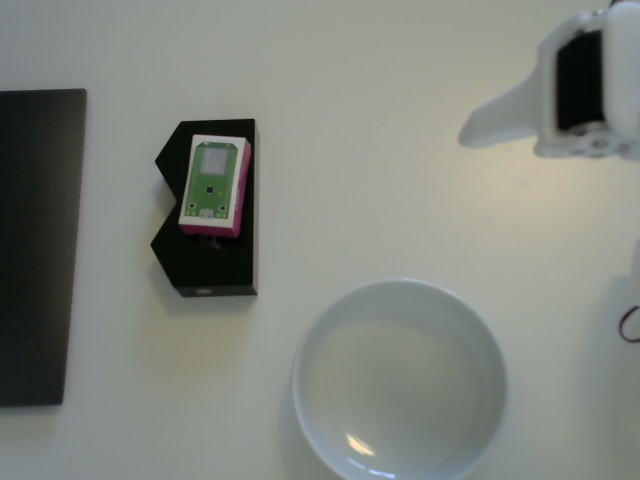

=== side (/dev/video1) ===


Corrupt JPEG data: 2 extraneous bytes before marker 0xd4


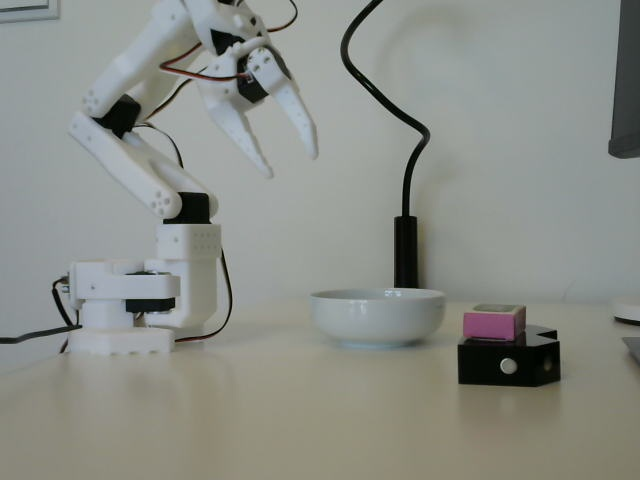

In [5]:
import cv2
from IPython.display import display, Image, HTML

cameras = {
    "front": "/dev/video3",
    "side":  "/dev/video1",
}

for name, dev in cameras.items():
    cap = cv2.VideoCapture(dev)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    ret, frame = cap.read()
    cap.release()

    if ret:
        print(f"=== {name} ({dev}) ===")
        _, buf = cv2.imencode(".jpg", frame)
        display(Image(data=buf.tobytes(), width=640))
    else:
        print(f"=== {name} ({dev}) === Failed to capture frame.")

## 3. Test Teleoperation with Cameras

Before recording a full dataset, verify that teleoperation works with both camera feeds.

Run the following in a **JupyterLab Terminal**:

```bash
lerobot-teleoperate \
    --robot.type=so101_follower \
    --robot.port=/dev/ttyACM0 \
    --robot.id=my_follower_arm \
    --robot.calibration_dir=/opt/workspace/lerobot/calibration \
    --robot.cameras='{ front: {type: opencv, index_or_path: /dev/video3, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}, side: {type: opencv, index_or_path: /dev/video1, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}}' \
    --teleop.type=so101_leader \
    --teleop.port=/dev/ttyACM1 \
    --teleop.id=my_leader_arm \
    --teleop.calibration_dir=/opt/workspace/lerobot/calibration \
    --display_data=false \
    2>&1 | grep -v "Corrupt JPEG"
```

> **Note:** `--display_data=true` requires a GUI display (X11/Wayland), which is not available in this headless Docker container. Use `--display_data=false` and check your camera angles with the notebook preview cell in Step 2 instead.

### Camera Parameters

| Parameter | Description | Recommended Value |
|:---|:---|:---|
| `type` | Camera backend | `opencv` |
| `index_or_path` | Device path from Step 2 | `/dev/video3` (front), `/dev/video1` (side) |
| `width` | Frame width in pixels | `640` |
| `height` | Frame height in pixels | `480` |
| `fps` | Frames per second | `30` |
| `fourcc` | Video codec | `MJPG` (compressed, higher fps) |
| `warmup_s` | Seconds to wait for first frame | `3` |

> **Tip:** `MJPG` format supports up to 3 cameras at 1920x1080 @ 30fps.
> Avoid connecting 2+ cameras through the same USB hub.

> **Important:** The camera key names (`front`, `side`) must remain **exactly the same** across teleoperation, recording, and evaluation. Mismatched names will cause errors during training.

## 4. Record a Dataset

Now we will record demonstration episodes. By setting `--dataset.root`, the data will be saved directly into the mounted workspace, which maps to `~/Warehouse/lerobot/local_data/my_dataset` on the host. This means the data **persists** even after the container stops.

Run the following in a **JupyterLab Terminal**:

```bash
lerobot-record \
    --robot.type=so101_follower \
    --robot.port=/dev/ttyACM0 \
    --robot.id=my_follower_arm \
    --robot.calibration_dir=/opt/workspace/lerobot/calibration \
    --robot.cameras='{ front: {type: opencv, index_or_path: /dev/video3, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}, side: {type: opencv, index_or_path: /dev/video1, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}}' \
    --teleop.type=so101_leader \
    --teleop.port=/dev/ttyACM1 \
    --teleop.id=my_leader_arm \
    --teleop.calibration_dir=/opt/workspace/lerobot/calibration \
    --display_data=false \
    --dataset.repo_id=local/my_dataset \
    --dataset.root=/opt/workspace/lerobot/local_data/my_dataset \
    --dataset.single_task="Pick up the object" \
    --dataset.num_episodes=5 \
    --dataset.episode_time_s=30 \
    --dataset.reset_time_s=30 \
    --dataset.push_to_hub=false \
    --play_sounds=false \
    2>&1 | grep -v "Corrupt JPEG"
```

> **Note:** `--dataset.root` is the **final dataset directory** that lerobot creates from scratch. It must **not** already exist. To re-record, delete the directory first (see "Resuming" section below).

### Recording Parameters

| Parameter | Description | Default |
|:---|:---|:---|
| `--dataset.repo_id` | Dataset identifier (used for Hub and metadata) | - |
| `--dataset.root` | Final dataset directory path (must not exist) | `~/.cache/huggingface/lerobot/{repo_id}` |
| `--dataset.single_task` | Task description string | - |
| `--dataset.num_episodes` | Number of episodes to record | `50` |
| `--dataset.episode_time_s` | Duration of each episode (seconds) | `60` |
| `--dataset.reset_time_s` | Time between episodes to reset the scene (seconds) | `60` |
| `--dataset.push_to_hub` | Upload to HuggingFace Hub | `true` |

> We set `--dataset.root=/opt/workspace/lerobot/local_data/my_dataset` so data is saved to the mounted workspace and persists on the host.
> We set `--dataset.push_to_hub=false` to keep the data local.

### Episode Flow (Headless Docker)

In a native Linux environment, lerobot supports keyboard controls during recording:

| Key | Action |
|:---|:---|
| Right arrow | End current episode early, move to next |
| Left arrow | Discard current episode, re-record |
| ESC | Stop recording, encode videos, save dataset |

> **Important:** These keyboard controls **do not work** in this Docker environment because `pynput` requires an X11 display, which is not available in a headless container. You will see a warning: *"Error trying to import pynput. Switching to headless mode."* This is expected.

In headless mode, episodes advance **automatically by timer**:

1. **Recording** -- perform the task for `episode_time_s` seconds (30s by default)
2. **Reset** -- reset the scene for `reset_time_s` seconds (30s by default)
3. Repeat until all `num_episodes` are recorded

The only way to stop early is `Ctrl+C`. All episodes recorded up to that point will be saved.

### Expected Terminal Output

If recording starts successfully, you should see logs like this:

```
INFO 2026-03-31 14:42:16 ls/utils.py:227 Recording episode 0
INFO 2026-03-31 14:42:46 ls/utils.py:227 Reset the environment
```

- **"Recording episode N"** means the system is actively capturing data. Teleoperate the robot to perform the task during this phase.
- **"Reset the environment"** means the current episode has finished. Reposition the objects and the robot to the starting pose before the next episode begins.

This cycle repeats for each episode. If you see these messages, everything is working correctly.

> **Tip:** Adjust `--dataset.episode_time_s` and `--dataset.reset_time_s` to match your task duration. Watch the terminal log for episode progress.

### Data Collection Tips

- **Keep cameras fixed** -- do not move cameras between episodes
- **Consistent behavior** -- perform the same grasping motion each time
- **Visible objects** -- ensure the target object is always in the camera frame
- **Start simple** -- begin with reliable grasps before adding variation
- Record at least **50 episodes** for reasonable training results

## 5. Inspect the Dataset

After recording, the dataset is saved at `/opt/workspace/lerobot/local_data/my_dataset` (i.e. `~/Warehouse/lerobot/local_data/my_dataset` on the host).

Let's verify the recorded data exists and inspect its structure.

In [5]:
from pathlib import Path

dataset_dir = Path("/opt/workspace/lerobot/local_data/my_dataset")

if dataset_dir.exists():
    print(f"Dataset found at: {dataset_dir}")
    print()
    for item in sorted(dataset_dir.rglob("*")):
        if item.is_file():
            size_mb = item.stat().st_size / (1024 * 1024)
            rel = item.relative_to(dataset_dir)
            print(f"  {rel}  ({size_mb:.1f} MB)")
else:
    print(f"Dataset not found at {dataset_dir}")
    print("Make sure you have completed the recording in Step 4.")

Dataset found at: /opt/workspace/lerobot/local_data/my_dataset

  data/chunk-000/file-000.parquet  (0.1 MB)
  meta/episodes/chunk-000/file-000.parquet  (0.1 MB)
  meta/info.json  (0.0 MB)
  meta/stats.json  (0.0 MB)
  meta/tasks.parquet  (0.0 MB)
  videos/observation.images.front/chunk-000/file-000.mp4  (10.1 MB)
  videos/observation.images.side/chunk-000/file-000.mp4  (22.4 MB)


Since the data is stored directly in the mounted workspace via `--dataset.root`, it automatically persists on the host at `~/Warehouse/lerobot/local_data/`. No manual copying is needed.

### Resuming or Extending a Recording

You can add more episodes to an existing dataset by re-running `lerobot-record` with `--resume=true`.

> **Important:** When resuming, `--dataset.num_episodes` specifies the number of **additional** episodes to record, **not** the total.

For example, if you already have 5 episodes (0-4) and want to reach 20 total, set `--dataset.num_episodes=15`:

```bash
lerobot-record \
    --robot.type=so101_follower \
    --robot.port=/dev/ttyACM0 \
    --robot.id=my_follower_arm \
    --robot.calibration_dir=/opt/workspace/lerobot/calibration \
    --robot.cameras='{ front: {type: opencv, index_or_path: /dev/video3, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}, side: {type: opencv, index_or_path: /dev/video1, width: 640, height: 480, fps: 30, fourcc: MJPG, warmup_s: 3}}' \
    --teleop.type=so101_leader \
    --teleop.port=/dev/ttyACM1 \
    --teleop.id=my_leader_arm \
    --teleop.calibration_dir=/opt/workspace/lerobot/calibration \
    --display_data=false \
    --dataset.repo_id=local/my_dataset \
    --dataset.root=/opt/workspace/lerobot/local_data/my_dataset \
    --dataset.single_task="Pick up the object" \
    --dataset.num_episodes=15 \
    --dataset.episode_time_s=30 \
    --dataset.reset_time_s=15 \
    --dataset.push_to_hub=false \
    --play_sounds=false \
    --resume=true \
    2>&1 | grep -v "Corrupt JPEG"
```

To start fresh instead, delete the dataset directory first:

```bash
rm -rf /opt/workspace/lerobot/local_data/my_dataset
```

### Conclusion

In this lab, you have successfully:

- Detected available cameras and identified their device indices
- Tested teleoperation with a live camera feed
- Recorded a demonstration dataset with motor states and camera observations
- Saved the dataset locally for offline use

This recorded dataset is the input for training imitation learning policies. In **RPD03**, you will use this data to train an ACT (Action Chunking with Transformers) policy and deploy it autonomously on the follower arm.

## Acknowledgements

This lab series builds on the [LeRobot](https://github.com/huggingface/lerobot) project -- the `lerobot-teleoperate`, `lerobot-record`, and `lerobot-train` tools, the **ACT** and **SmolVLA** policies -- and the open-hardware **SO-101** arm from [TheRobotStudio / Hugging Face](https://github.com/TheRobotStudio/SO-ARM100). Training and inference run on AMD Ryzen AI (Radeon gfx1152) with ROCm.


---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
